In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
categories = pd.read_csv('../data/csv/categories.csv')
customers = pd.read_csv('../data/csv/customers.csv')
employees = pd.read_csv('../data/csv/employees.csv')
orders = pd.read_csv('../data/csv/orders.csv')
order_details = pd.read_csv('../data/csv/orderDetails.csv')
products = pd.read_csv('../data/csv/products.csv')
suppliers = pd.read_csv('../data/csv/suppliers.csv')
shippers = pd.read_csv('../data/csv/shippers.csv')

In [4]:
df_products_order_details_categories = pd.read_csv('../data/csv/order_details_products_categories.csv')
display(df_products_order_details_categories)

,id_order_detail,order_id,product_id,quantity,id_product,name,supplier_id,category_id,unit,price,id,name_category,description
0,1,10248,11,12,11,Queso Cabrales,5,4,1 kg pkg.,21.00,4,Dairy Products,Cheeses
1,2,10248,42,10,42,Singaporean Hokkien Fried Mee,20,5,32 - 1 kg pkgs.,14.00,5,Grains/Cereals,"Breads, crackers, pasta, and cereal"
2,3,10248,72,5,72,Mozzarella di Giovanni,14,4,24 - 200 g pkgs.,34.80,4,Dairy Products,Cheeses
3,4,10249,14,9,14,Tofu,6,7,40 - 100 g pkgs.,23.25,7,Produce,Dried fruit and bean curd
4,5,10249,51,40,51,Manjimup Dried Apples,24,7,50 - 300 g pkgs.,53.00,7,Produce,Dried fruit and bean curd
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,514,10442,11,30,11,Queso Cabrales,5,4,1 kg pkg.,21.00,4,Dairy Products,Cheeses
514,515,10442,54,80,54,Tourtière,25,6,16 pies,7.45,6,Meat/Poultry,Prepared meats
515,516,10442,66,60,66,Louisiana Hot Spiced Okra,2,2,24 - 8 oz jars,17.00,2,Condiments,"Sweet and savory sauces, relishes, spreads, an..."
516,517,10443,11,6,11,Queso Cabrales,5,4,1 kg pkg.,21.00,4,Dairy Products,Cheeses


In [5]:
categories = df_products_order_details_categories.groupby('name_category')['name'].unique().apply(list)

categoriess = np.array(categories.keys())
product_names = np.array(categories.values)

display(product_names)

array([list(['Chartreuse verte', 'Guaraná Fantástica', 'Chang', 'Outback Lager', 'Steeleye Stout', 'Lakkalikööri', 'Ipoh Coffee', 'Rhönbräu Klosterbier', 'Laughing Lumberjack Lager', 'Chais', 'Sasquatch Ale', 'Côte de Blaye']),
       list(['Louisiana Fiery Hot Pepper Sauce', 'Original Frankfurter grüne Soße', "Chef Anton's Gumbo Mix", 'Gula Malacca', 'Vegie-spread', 'Genen Shouyu', 'Aniseed Syrup', 'Louisiana Hot Spiced Okra', "Chef Anton's Cajun Seasoning", "Grandma's Boysenberry Spread", 'Northwoods Cranberry Sauce', "Sirop d'érable"]),
       list(["Sir Rodney's Marmalade", 'Maxilaku', 'Pavlova', 'Schoggi Schokolade', "Sir Rodney's Scones", 'Tarte au sucre', 'Teatime Chocolate Biscuits', 'Scottish Longbreads', 'NuNuCa Nuß-Nougat-Creme', 'Gumbär Gummibärchen', 'Zaanse koeken', 'Valkoinen suklaa', 'Chocolade']),
       list(['Queso Cabrales', 'Mozzarella di Giovanni', 'Geitost', 'Camembert Pierrot', 'Gorgonzola Telino', 'Raclette Courdavault', 'Mascarpone Fabioli', 'Queso Manchego La

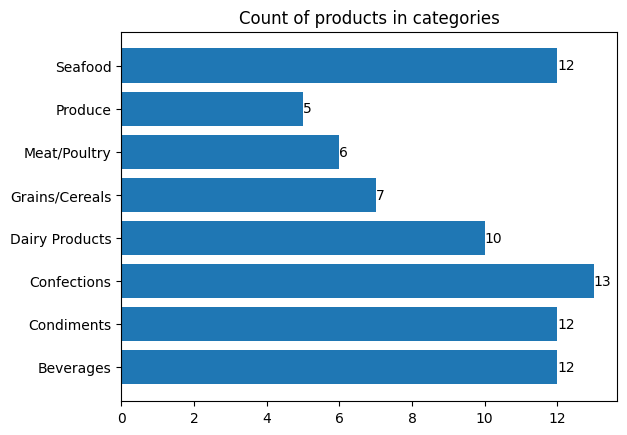

In [7]:
products_count = df_products_order_details_categories.groupby('name_category')['name'].nunique()

category_names = np.array(products_count.keys())
product_cnames = np.array(products_count.values)

plt.barh(category_names, product_cnames)

for i, x in enumerate(product_cnames):
    plt.text(x, i, str(f'{x}'), va='center', fontsize=10) 

plt.title("Count of products in categories")

plt.show()

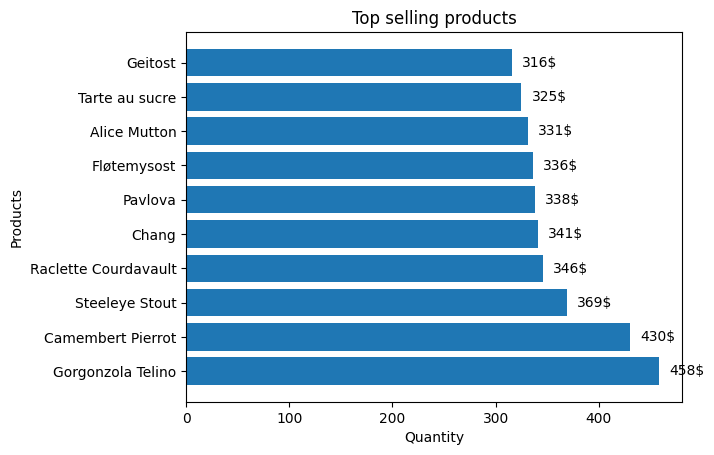

In [11]:
products_quantity = df_products_order_details_categories.groupby('name')['quantity'].sum().sort_values(ascending=False)[:10]
names = np.array(products_quantity.keys())
quantities = np.array(products_quantity.values)

plt.barh(names, quantities)

for i, qty in enumerate(quantities):
    plt.text(qty + 10, i, str(f'{qty}$'), va='center', fontsize=10) 

plt.title("Top selling products")
plt.xlabel("Quantity")
plt.ylabel("Products")

plt.show()

In [9]:
products_categories = df_products_order_details_categories.groupby('name_category')['name'].unique().apply(list)

for category, products in products_categories.items():
    products_str = ", ".join(products)  
    print(f'{category} - {products_str}')

Beverages - Chartreuse verte, Guaraná Fantástica, Chang, Outback Lager, Steeleye Stout, Lakkalikööri, Ipoh Coffee, Rhönbräu Klosterbier, Laughing Lumberjack Lager, Chais, Sasquatch Ale, Côte de Blaye
Condiments - Louisiana Fiery Hot Pepper Sauce, Original Frankfurter grüne Soße, Chef Anton's Gumbo Mix, Gula Malacca, Vegie-spread, Genen Shouyu, Aniseed Syrup, Louisiana Hot Spiced Okra, Chef Anton's Cajun Seasoning, Grandma's Boysenberry Spread, Northwoods Cranberry Sauce, Sirop d'érable
Confections - Sir Rodney's Marmalade, Maxilaku, Pavlova, Schoggi Schokolade, Sir Rodney's Scones, Tarte au sucre, Teatime Chocolate Biscuits, Scottish Longbreads, NuNuCa Nuß-Nougat-Creme, Gumbär Gummibärchen, Zaanse koeken, Valkoinen suklaa, Chocolade
Dairy Products - Queso Cabrales, Mozzarella di Giovanni, Geitost, Camembert Pierrot, Gorgonzola Telino, Raclette Courdavault, Mascarpone Fabioli, Queso Manchego La Pastora, Fløtemysost, Gudbrandsdalsost
Grains/Cereals - Singaporean Hokkien Fried Mee, Gustaf

In [10]:
products_price = df_products_order_details_categories.groupby('price')['name'].unique()[:10].apply(list)

print(products_price)

price
2.50                                             [Geitost]
4.50                                  [Guaraná Fantástica]
6.00                                               [Konbu]
7.00                                            [Filo Mix]
7.45                                           [Tourtière]
7.75                                [Rhönbräu Klosterbier]
9.00                                            [Tunnbröd]
9.20                          [Teatime Chocolate Biscuits]
9.50                          [Zaanse koeken, Røgede sild]
9.65                     [Jack's New England Clam Chowder]
10.00    [Longlife Tofu, Sir Rodney's Scones, Aniseed S...
Name: name, dtype: object


C:\Users\todor\AppData\Local\Temp\ipykernel_18076\1368737621.py:1: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  products_price = df_products_order_details_categories.groupby('price')['name'].unique()[:10].apply(list)


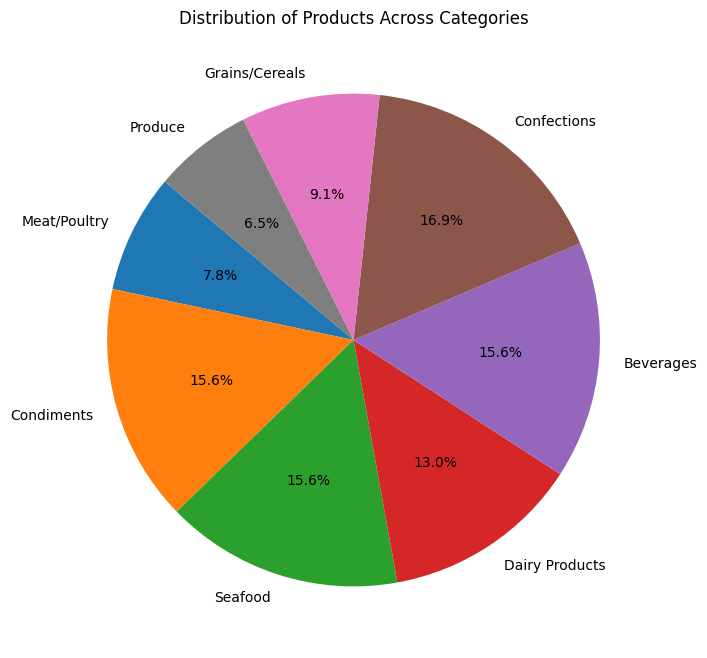

In [ ]:

product_price_category = (
    df_products_order_details_categories
    .groupby('name')
    .agg({
        'price': 'mean',  
        'name_category': lambda x: list(x.unique())
    })
    .reset_index()
)

from collections import Counter

all_categories = sum(product_price_category['name_category'], [])
category_counts = dict(Counter(all_categories))

plt.figure(figsize=(8, 8))
plt.pie(category_counts.values(), labels=category_counts.keys(), autopct='%1.1f%%', startangle=140)
plt.title('Distribution of Products Across Categories')
plt.show()
